In [85]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from xgboost import XGBRegressor

In [71]:
df=pd.read_csv("AmesHousing.csv")
df.sample(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2208,2209,909256120,30,RL,50.0,6305,Pave,NaN,Reg,Bnk,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,119750
1656,1657,527357020,20,RL,128.0,13001,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,9,2007,WD,Normal,170000
2658,2659,902305090,70,RM,60.0,9600,Pave,Grvl,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,87000
644,645,535304100,20,RL,67.0,13070,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,126000
385,386,527366030,60,FV,NaN,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2009,WD,Normal,220000


In [72]:
df.shape

(2930, 82)

In [73]:
df['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [74]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

<Axes: >

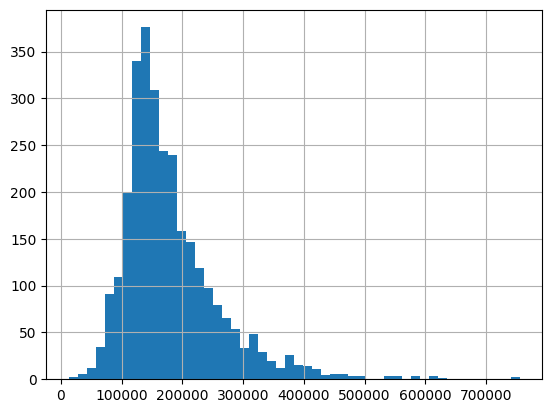

In [75]:
df['SalePrice'].hist(bins=50)

In [76]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [77]:
# MISSING VALUE HANDLING
# NaN in these means "None" (no pool, no fence, no garage, etc.)
none_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
             'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
             'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
             'Mas Vnr Type']
for col in none_cols:
    df[col] = df[col].fillna('None')

# NaN in these numeric cols usually means 0 (no basement/garage → 0 sqft)
zero_cols = ['Garage Yr Blt', 'Garage Area', 'Garage Cars', 'BsmtFin SF 1', 'BsmtFin SF 2',
             'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Mas Vnr Area']
for col in zero_cols:
    df[col] = df[col].fillna(0)

# LotFrontage - fill with neighborhood median (spatial logic)
df['LotFrontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(
    lambda x: x.fillna(x.median())
)

In [78]:
# FEATURE ENGINEERING
df['HouseAge'] = df['Yr Sold'] - df['Year Built']
df['YearsSinceRemodel'] = df['Yr Sold'] - df['Year Remod/Add']
df['TotalSF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']
df['TotalBathrooms'] = (df['Full Bath'] + 0.5*df['Half Bath'] +
                         df['Bsmt Full Bath'] + 0.5*df['Bsmt Half Bath'])
df['HasPool'] = (df['Pool Area'] > 0).astype(int)
df['HasGarage'] = (df['Garage Area'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['Remodeled'] = (df['Year Built'] != df['Year Remod/Add']).astype(int)

In [79]:
# ENCODING STRATEGY
# 1. Ordinal columns with REAL rank order (Ex > Gd > TA > Fa > Po > None)
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_qual_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond',
                      'Heating QC', 'Kitchen Qual', 'Fireplace Qu',
                      'Garage Qual', 'Garage Cond', 'Pool QC']
for col in ordinal_qual_cols:
    df[col] = df[col].map(quality_map)

high_card_cols = ['Neighborhood', 'Exterior 1st', 'Exterior 2nd', 'Sale Type']
remaining_cat_cols = [c for c in df.select_dtypes(include='object').columns
                       if c not in high_card_cols]

C:\Users\KRISHNA YADAV\AppData\Local\Temp\ipykernel_9584\3589144132.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_cat_cols = [c for c in df.select_dtypes(include='object').columns


In [80]:
# DEFINE X/Y COLUMNS
drop_cols = ['SalePrice', 'Order', 'PID']  # PID/Order are IDs, not features
X = df.drop(columns=drop_cols)
y = df['SalePrice']

cat_cols = high_card_cols + remaining_cat_cols
cat_cols = [c for c in cat_cols if c in X.columns]

In [81]:
# PIPELINE
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         cat_cols)
    ],
    remainder='passthrough'  # numeric + already-mapped quality columns pass through
)

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

In [82]:
# log transformer
model = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1
)

In [83]:
# train_test_split + model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_percentage_error
print("R2:", r2_score(y_test, preds))
print("MAPE:", mean_absolute_percentage_error(y_test, preds))

R2: 0.9438371658325195
MAPE: 0.07194089144468307
